# OPD Antibiotic Prescribing — Exploratory Data Analysis

| | |
|---|---|
| **Study** | Developing a Framework for Rational Prescription of Antibiotics in EMR |
| **Institution** | Lady Ridgeway Hospital for Children, Colombo |
| **Researcher** | Dr. Chinthaka Jayarathne, MD Health Informatics Batch 05, PGIM |
| **Data** | March 2023 – March 2026, HHIMS pseudonymised OPD dataset |
| **Input file** | `opd_prepared.csv` (output of data preparation notebook) |

---

## Sections
1. Setup & Data Load
2. Dataset Overview
3. Antibiotic Prescribing — Core Outcome
4. Patient Profile
5. Complaint Profile
6. Prescriber Behaviour
7. Temporal Patterns
8. Feature Relationships

---
## Section 1 — Setup & Data Load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 40)
pd.set_option('display.float_format', '{:.2f}'.format)

# ── CONFIGURE PATHS ──────────────────────────────────────────────────────────
PREPARED_DATA = r'D:/Academic/MD Research 2025/AMS_2026/opd_prepared.csv'
FIGURES_DIR   = r'D:/Academic/MD Research 2025/AMS_2026/EDA_figures'

os.makedirs(FIGURES_DIR, exist_ok=True)

# ── HELPER — save figure ─────────────────────────────────────────────────────
def savefig(name):
    path = os.path.join(FIGURES_DIR, f'{name}.png')
    plt.savefig(path, dpi=150, bbox_inches='tight')
    print(f'  Saved: {path}')

print('Setup complete.')

Setup complete.


In [2]:
# Load prepared dataset
df = pd.read_csv(PREPARED_DATA, low_memory=False)
df['DateTimeOfVisit'] = pd.to_datetime(df['DateTimeOfVisit'], errors='coerce')

print(f'Loaded: {len(df):,} encounters, {df.shape[1]} columns')
print(f'Date range: {df["DateTimeOfVisit"].min().date()} to {df["DateTimeOfVisit"].max().date()}')
df.head(3).T

Loaded: 653,926 encounters, 33 columns
Date range: 2023-03-01 to 2026-01-31


,0,1,2
OPDID,35264,35267,35268
patient_pseudo_id,4568a69a7836afa716a028dff73efa21d991...,89f46a2fd97e08b46c3e009a4c4392ea9bee...,d9610fe238c741ec4e8408c4b3c9ced8c6b8...
DateTimeOfVisit,2023-03-01 07:16:00,2023-03-01 07:21:00,2023-03-01 07:23:00
Complaint,cough,c,c
PatientWeight,NaN,NaN,NaN
age_months,35,144,18
age_stratum,preschool_2_4y,adolescent_12_17y,toddler_12_23m
Gender,Female,Female,Female
prescriber_pseudo_id,b5da42655880d43181303fbfadd2f9ef24ee...,7671f597cb33d7e93d2fbf30e4f3e8ffc1c1...,7671f597cb33d7e93d2fbf30e4f3e8ffc1c1...
num_distinct_drugs,5,2,3


---
## Section 2 — Dataset Overview

In [3]:
# ── Basic counts ─────────────────────────────────────────────────────────────
print('=' * 55)
print('DATASET OVERVIEW')
print('=' * 55)
print(f'  Total encounters      : {len(df):,}')
print(f'  Unique patients       : {df["patient_pseudo_id"].nunique():,}')
print(f'  Unique prescribers    : {df["prescriber_pseudo_id"].nunique():,}')
print(f'  Date range            : {df["DateTimeOfVisit"].min().date()} '
      f'to {df["DateTimeOfVisit"].max().date()}')
print(f'  Total columns         : {df.shape[1]}')

DATASET OVERVIEW
  Total encounters      : 653,926
  Unique patients       : 183,254
  Unique prescribers    : 131
  Date range            : 2023-03-01 to 2026-01-31
  Total columns         : 33


In [4]:
# ── Missing values ────────────────────────────────────────────────────────────
missing = df.isnull().sum()
missing_pct = (df.isnull().mean() * 100).round(1)
missing_df = pd.DataFrame({'Missing count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing count'] > 0].sort_values('Missing %', ascending=False)

print('Columns with missing values:')
print(missing_df.to_string())

Columns with missing values:
                         Missing count  Missing %
complaint_duration_days         530304      81.10
aware_categories                312021      47.70
antibiotic_groups               312021      47.70
antibiotic_routes               312021      47.70
antibiotic_compounds            312021      47.70
symptom_tags                     31397       4.80
PatientWeight                    28600       4.40
drug_groups                       1137       0.20


  Saved: D:/Academic/MD Research 2025/AMS_2026/EDA_figures\01_missing_values_heatmap.png


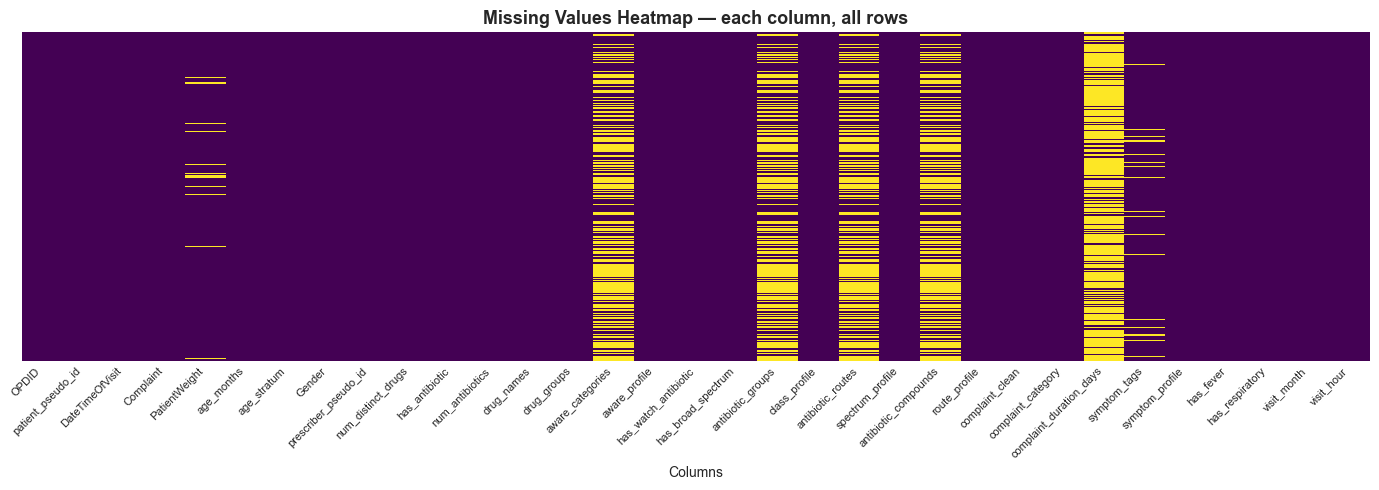

In [5]:
# ── Missing values heatmap ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', ax=ax, yticklabels=False)
ax.set_title('Missing Values Heatmap — each column, all rows', fontsize=13, fontweight='bold')
ax.set_xlabel('Columns')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
savefig('01_missing_values_heatmap')
plt.show()

In [6]:
# ── Data types summary ────────────────────────────────────────────────────────
df.dtypes

OPDID                               int64
patient_pseudo_id                     str
DateTimeOfVisit            datetime64[us]
Complaint                             str
PatientWeight                     float64
age_months                            str
age_stratum                           str
Gender                                str
prescriber_pseudo_id                  str
num_distinct_drugs                  int64
has_antibiotic                      int64
num_antibiotics                     int64
drug_names                            str
drug_groups                           str
aware_categories                      str
aware_profile                         str
has_watch_antibiotic                int64
has_broad_spectrum                  int64
antibiotic_groups                     str
class_profile                         str
antibiotic_routes                     str
spectrum_profile                      str
antibiotic_compounds                  str
route_profile                     

---
## Section 3 — Antibiotic Prescribing — Core Outcome

In [7]:
# ── Overall antibiotic rate ───────────────────────────────────────────────────
total         = len(df)
ab_n          = df['has_antibiotic'].sum()
ab_rate       = ab_n / total * 100
watch_n       = df['has_watch_antibiotic'].sum()
broad_n       = df['has_broad_spectrum'].sum()
combo_n       = (df['num_antibiotics'] >= 2).sum()

print('=' * 55)
print('ANTIBIOTIC PRESCRIBING — CORE METRICS')
print('=' * 55)
print(f'  Encounters with antibiotic   : {ab_n:,} ({ab_rate:.1f}%)')
print(f'  Encounters without antibiotic: {total - ab_n:,} ({100 - ab_rate:.1f}%)')
print(f'  Watch antibiotic prescribed  : {watch_n:,} ({100*watch_n/total:.1f}%)')
print(f'  Broad-spectrum antibiotic    : {broad_n:,} ({100*broad_n/total:.1f}%)')
print(f'  Combination (2+ antibiotics) : {combo_n:,} ({100*combo_n/total:.1f}%)')

ANTIBIOTIC PRESCRIBING — CORE METRICS
  Encounters with antibiotic   : 319,454 (48.9%)
  Encounters without antibiotic: 334,472 (51.1%)
  Watch antibiotic prescribed  : 39,134 (6.0%)
  Broad-spectrum antibiotic    : 76,484 (11.7%)
  Combination (2+ antibiotics) : 18,566 (2.8%)


  Saved: D:/Academic/MD Research 2025/AMS_2026/EDA_figures\02_antibiotic_rate_overview.png


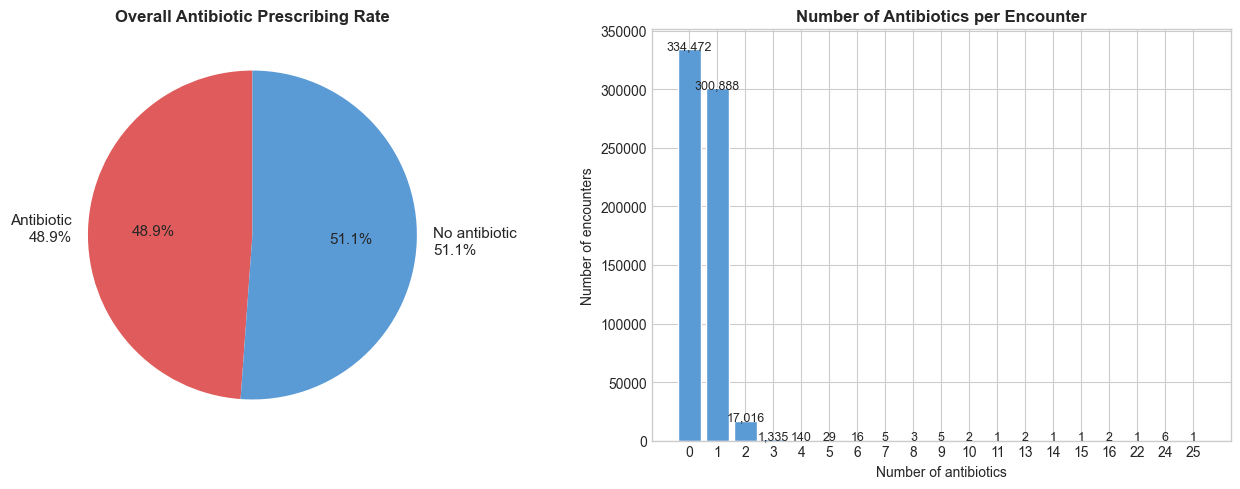

In [8]:
# ── Antibiotic vs no antibiotic pie ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Pie: antibiotic vs no antibiotic
vals   = [ab_n, total - ab_n]
labels = [f'Antibiotic\n{ab_rate:.1f}%', f'No antibiotic\n{100-ab_rate:.1f}%']
colors = ['#E05C5C', '#5B9BD5']
axes[0].pie(vals, labels=labels, colors=colors, autopct='%1.1f%%',
            startangle=90, textprops={'fontsize': 11})
axes[0].set_title('Overall Antibiotic Prescribing Rate', fontweight='bold')

# Bar: num_antibiotics distribution
num_ab_counts = df['num_antibiotics'].value_counts().sort_index()
axes[1].bar(num_ab_counts.index.astype(str), num_ab_counts.values,
            color='#5B9BD5', edgecolor='white')
axes[1].set_title('Number of Antibiotics per Encounter', fontweight='bold')
axes[1].set_xlabel('Number of antibiotics')
axes[1].set_ylabel('Number of encounters')
for i, v in enumerate(num_ab_counts.values):
    axes[1].text(i, v + 200, f'{v:,}', ha='center', fontsize=9)

plt.tight_layout()
savefig('02_antibiotic_rate_overview')
plt.show()

In [9]:
# ── AWaRe profile distribution ────────────────────────────────────────────────
aware_counts = df['aware_profile'].value_counts()
print('AWaRe Profile distribution:')
for k, v in aware_counts.items():
    print(f'  {k:<30} : {v:>7,}  ({100*v/total:.1f}%)')

AWaRe Profile distribution:
  No antibiotic                  : 312,021  (47.7%)
  Access-only                    : 259,375  (39.7%)
  Watch-only                     :  33,669  (5.1%)
  Not classified                 :  24,976  (3.8%)
  Mixed                          :  23,885  (3.7%)


  Saved: D:/Academic/MD Research 2025/AMS_2026/EDA_figures\03_aware_profile.png


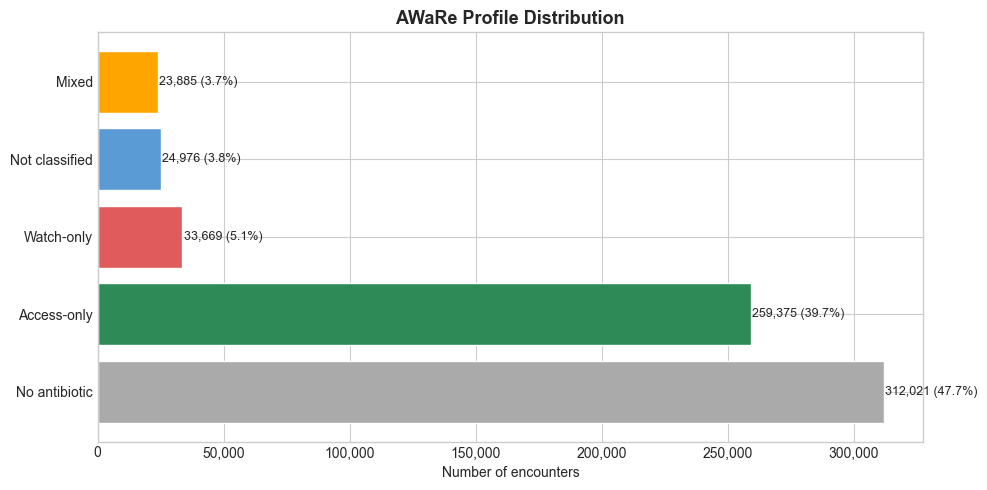

In [10]:
# ── AWaRe profile bar chart ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
aware_colors = {
    'Access-only':  '#2E8B57',
    'Watch-only':   '#E05C5C',
    'Mixed':        '#FFA500',
    'Reserve-only': '#8B0000',
    'No antibiotic':'#AAAAAA',
}
bar_colors = [aware_colors.get(k, '#5B9BD5') for k in aware_counts.index]
bars = ax.barh(aware_counts.index, aware_counts.values,
               color=bar_colors, edgecolor='white')
for bar, v in zip(bars, aware_counts.values):
    ax.text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2,
            f'{v:,} ({100*v/total:.1f}%)', va='center', fontsize=9)
ax.set_title('AWaRe Profile Distribution', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of encounters')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
savefig('03_aware_profile')
plt.show()

  Saved: D:/Academic/MD Research 2025/AMS_2026/EDA_figures\04_top_antibiotics.png


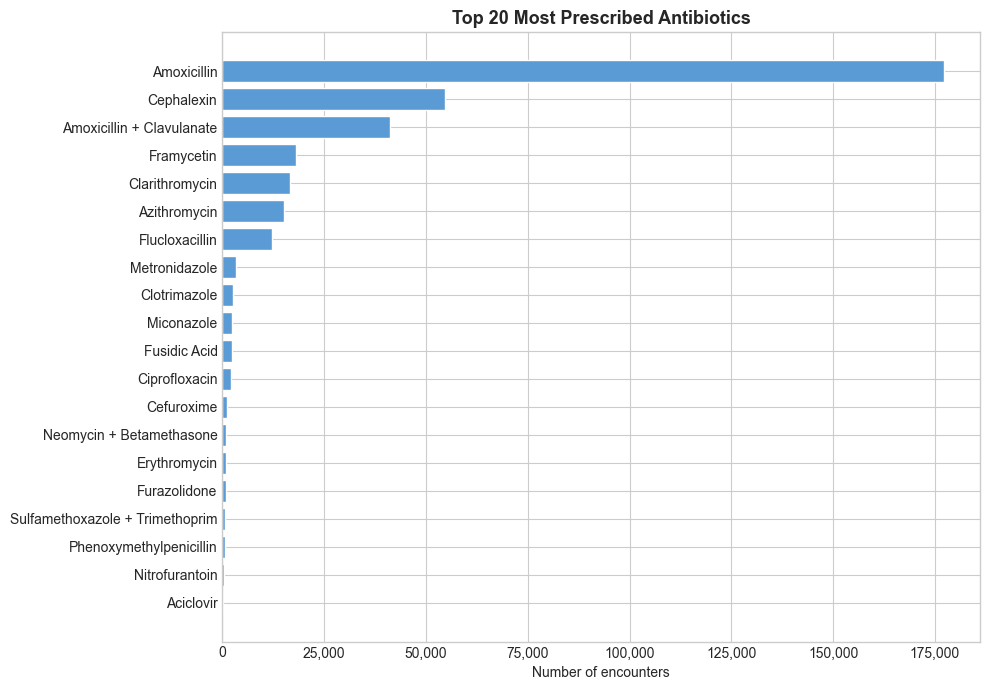

In [11]:
# ── Top 20 most prescribed antibiotics ───────────────────────────────────────
top_ab = (
    df[df['has_antibiotic'] == 1]['antibiotic_compounds']
    .dropna()
    .str.split('|')
    .explode()
    .str.strip()
    .value_counts()
    .head(20)
)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top_ab.index[::-1], top_ab.values[::-1], color='#5B9BD5', edgecolor='white')
ax.set_title('Top 20 Most Prescribed Antibiotics', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of encounters')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
savefig('04_top_antibiotics')
plt.show()

In [12]:
# ── Antibiotic class profile distribution ────────────────────────────────────
class_counts = (
    df[df['has_antibiotic'] == 1]['class_profile']
    .value_counts()
    .head(15)
)
print('Top 15 antibiotic class profiles:')
for k, v in class_counts.items():
    print(f'  {k:<40} : {v:>6,}')

Top 15 antibiotic class profiles:
  Aminopenicillin                          : 164,764
  1st Gen. Cephalosporin                   : 50,824
  Aminopenicillin + BLI                    : 33,143
  Macrolide                                : 29,481
  Penicillinase-resistant Penicillin       :  4,232
  Aminoglycoside (Framycetin)/Penicillinase-resistant Penicillin :  3,866
  Aminoglycoside (Framycetin)/Aminopenicillin :  3,859
  Aminoglycoside (Framycetin)              :  3,004
  Aminoglycoside (Framycetin)/Aminopenicillin + BLI :  2,782
  Aminopenicillin/Antifungal               :  2,200
  Aminopenicillin + BLI/Penicillinase-resistant Penicillin :  1,414
  Aminopenicillin/Nitroimidazole           :  1,342
  1st Gen. Cephalosporin/Aminoglycoside (Framycetin) :  1,289
  Nitrofuran                               :  1,089
  Fusidic Acid                             :  1,071


---
## Section 4 — Patient Profile

In [13]:
# ── Age distribution ──────────────────────────────────────────────────────────
print('Age summary (months):')
print(df['age_months'].describe().to_string())

print('\nAge stratum distribution:')
age_order = [
    'neonate_0_27d', 'infant_1_2m', 'infant_3_5m', 'infant_6_11m',
    'toddler_12_23m', 'preschool_2_4y', 'child_5_11y',
    'adolescent_12_17y', 'adult_18plus'
]
age_counts = df['age_stratum'].value_counts().reindex(
    [a for a in age_order if a in df['age_stratum'].values]
)
for k, v in age_counts.items():
    print(f'  {k:<22} : {v:>7,}  ({100*v/total:.1f}%)')

Age summary (months):
count     653926
unique       276
top            7
freq        7128

Age stratum distribution:
  neonate_0_27d          :   1,350  (0.2%)
  infant_1_2m            :   8,349  (1.3%)
  infant_3_5m            :  16,535  (2.5%)
  infant_6_11m           :  40,660  (6.2%)
  toddler_12_23m         :  69,257  (10.6%)
  preschool_2_4y         : 178,782  (27.3%)
  child_5_11y            : 297,010  (45.4%)
  adolescent_12_17y      :  41,874  (6.4%)
  adult_18plus           :     109  (0.0%)


  Saved: D:/Academic/MD Research 2025/AMS_2026/EDA_figures\05_patient_profile.png


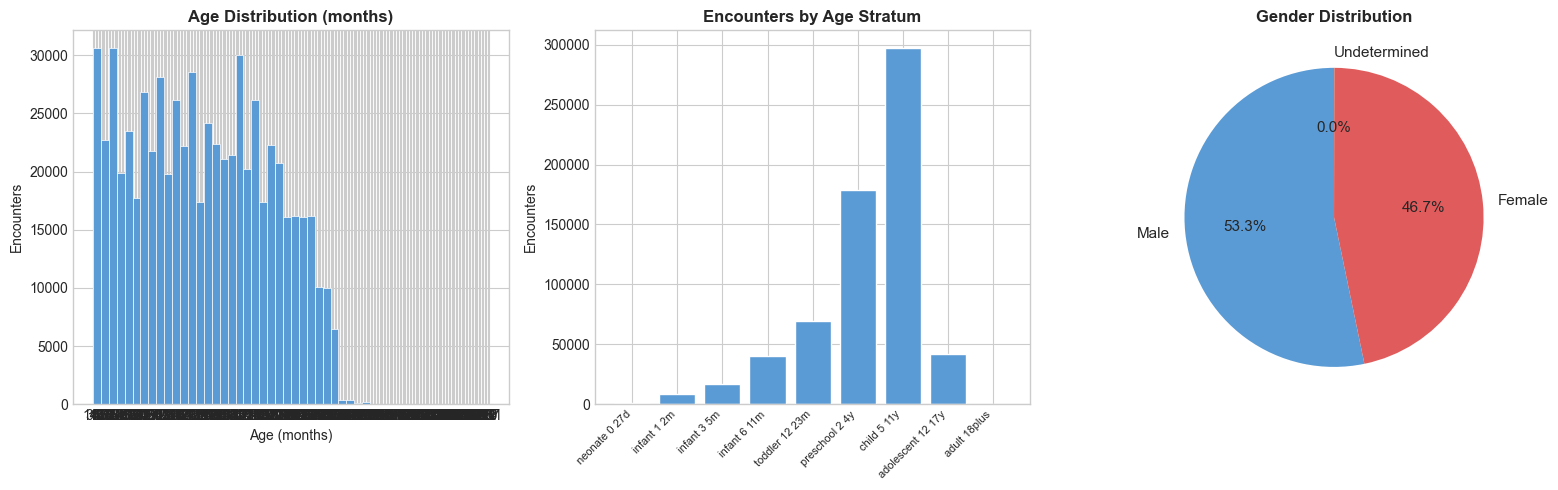

In [14]:
# ── Age and gender charts ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Age histogram
axes[0].hist(df['age_months'].dropna(), bins=50, color='#5B9BD5',
             edgecolor='white', linewidth=0.5)
axes[0].set_title('Age Distribution (months)', fontweight='bold')
axes[0].set_xlabel('Age (months)')
axes[0].set_ylabel('Encounters')

# Age stratum bar
present_strata = [a for a in age_order if a in df['age_stratum'].values]
age_vals = df['age_stratum'].value_counts().reindex(present_strata)
short_labels = [a.replace('_', ' ') for a in present_strata]
axes[1].bar(range(len(age_vals)), age_vals.values, color='#5B9BD5', edgecolor='white')
axes[1].set_xticks(range(len(age_vals)))
axes[1].set_xticklabels(short_labels, rotation=45, ha='right', fontsize=8)
axes[1].set_title('Encounters by Age Stratum', fontweight='bold')
axes[1].set_ylabel('Encounters')

# Gender pie
gender_counts = df['Gender'].value_counts()
axes[2].pie(gender_counts.values, labels=gender_counts.index,
            autopct='%1.1f%%', startangle=90,
            colors=['#5B9BD5', '#E05C5C', '#A8D5A2'],
            textprops={'fontsize': 11})
axes[2].set_title('Gender Distribution', fontweight='bold')

plt.tight_layout()
savefig('05_patient_profile')
plt.show()

In [15]:
# ── Weight distribution ───────────────────────────────────────────────────────
print('Weight summary (kg) — after zero replacement:')
print(df['PatientWeight'].describe().to_string())
print(f"\nMissing weight: {df['PatientWeight'].isna().sum():,} "
      f"({100*df['PatientWeight'].isna().mean():.1f}%)")

Weight summary (kg) — after zero replacement:
count   625326.00
mean        18.97
std         23.04
min        -16.70
25%         11.00
50%         15.85
75%         23.15
max       1000.00

Missing weight: 28,600 (4.4%)


  Saved: D:/Academic/MD Research 2025/AMS_2026/EDA_figures\06_ab_rate_by_age.png


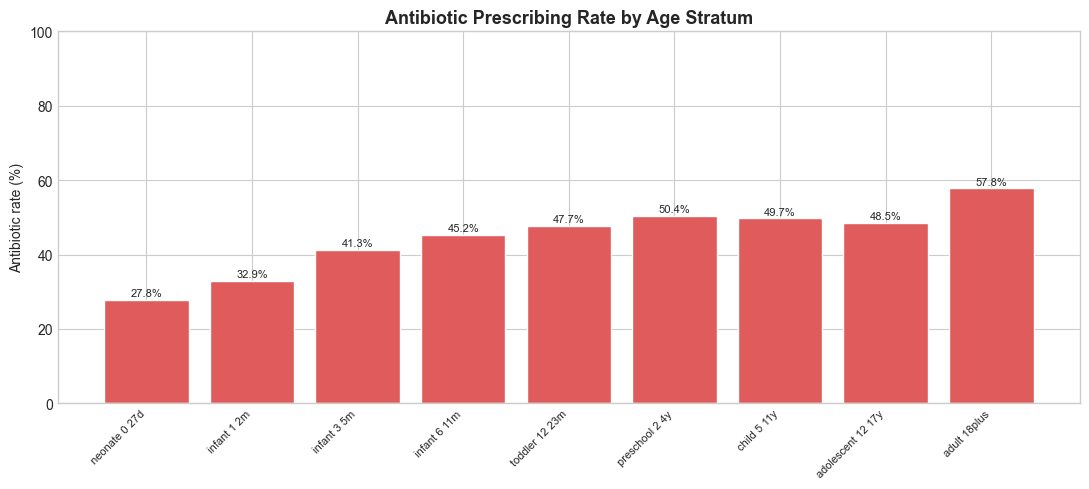

In [16]:
# ── Antibiotic rate by age stratum ────────────────────────────────────────────
ab_by_age = (
    df.groupby('age_stratum')['has_antibiotic']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'ab_rate', 'count': 'n'})
    .reindex([a for a in age_order if a in df['age_stratum'].values])
)
ab_by_age['ab_rate_pct'] = (ab_by_age['ab_rate'] * 100).round(1)

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(range(len(ab_by_age)),
              ab_by_age['ab_rate_pct'],
              color='#E05C5C', edgecolor='white')
ax.set_xticks(range(len(ab_by_age)))
ax.set_xticklabels([a.replace('_', ' ') for a in ab_by_age.index],
                   rotation=45, ha='right', fontsize=8)
ax.set_title('Antibiotic Prescribing Rate by Age Stratum', fontsize=13, fontweight='bold')
ax.set_ylabel('Antibiotic rate (%)')
ax.set_ylim(0, 100)
for bar, (_, row) in zip(bars, ab_by_age.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 1,
            f"{row['ab_rate_pct']}%",
            ha='center', fontsize=8)
plt.tight_layout()
savefig('06_ab_rate_by_age')
plt.show()

In [17]:
# ── Antibiotic rate by gender ─────────────────────────────────────────────────
ab_by_gender = (
    df.groupby('Gender')['has_antibiotic']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'ab_rate', 'count': 'n'})
)
ab_by_gender['ab_rate_pct'] = (ab_by_gender['ab_rate'] * 100).round(1)
print('Antibiotic rate by gender:')
print(ab_by_gender[['n', 'ab_rate_pct']].to_string())

Antibiotic rate by gender:
                   n  ab_rate_pct
Gender                           
Female        305554        48.50
Male          348253        49.20
Undetermined     119        44.50


---
## Section 5 — Complaint Profile

In [18]:
# ── Complaint category distribution ──────────────────────────────────────────
cat_counts = df['complaint_category'].value_counts()
print('Complaint category distribution:')
for k, v in cat_counts.items():
    print(f'  {k:<25} : {v:>7,}  ({100*v/total:.1f}%)')

Complaint category distribution:
  Respiratory-URTI          : 295,535  (45.2%)
  Multi-system              : 126,147  (19.3%)
  Fever                     :  84,962  (13.0%)
  Skin                      :  51,137  (7.8%)
  GI                        :  33,667  (5.1%)
  Unclassified              :  31,397  (4.8%)
  ENT                       :  12,846  (2.0%)
  Respiratory-Wheeze        :  11,794  (1.8%)
  Neuro                     :   3,521  (0.5%)
  UTI                       :   1,628  (0.2%)
  Musculo                   :   1,163  (0.2%)
  Respiratory-LRTI          :     129  (0.0%)


  Saved: D:/Academic/MD Research 2025/AMS_2026/EDA_figures\07_complaint_profile.png


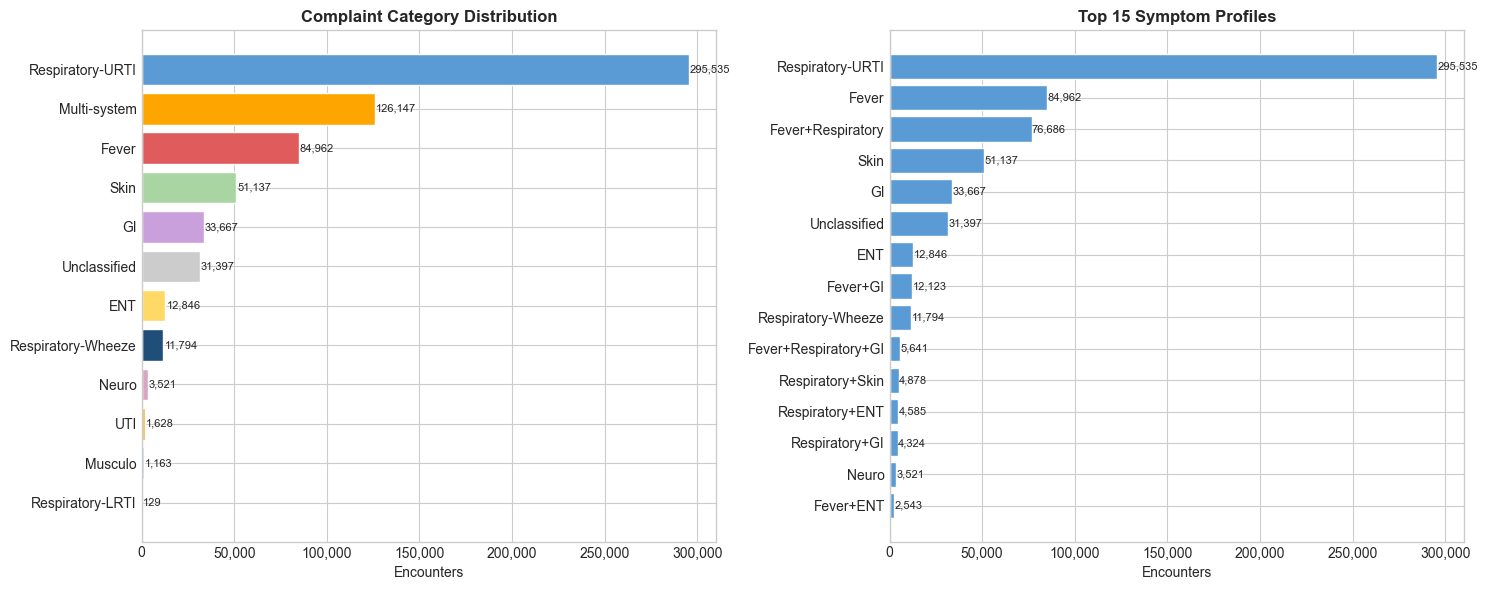

In [19]:
# ── Complaint category bar chart ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# complaint_category
cat_colors = {
    'Respiratory-URTI':   '#5B9BD5',
    'Respiratory-Wheeze': '#1F4E79',
    'Respiratory-LRTI':   '#002060',
    'Fever':              '#E05C5C',
    'Multi-system':       '#FFA500',
    'Skin':               '#A8D5A2',
    'GI':                 '#C9A0DC',
    'ENT':                '#FFD966',
    'UTI':                '#F4B942',
    'Neuro':              '#D9A6C2',
    'Musculo':            '#B5D0E0',
    'Unclassified':       '#CCCCCC',
}
colors_list = [cat_colors.get(k, '#888888') for k in cat_counts.index]
bars = axes[0].barh(cat_counts.index[::-1], cat_counts.values[::-1],
                    color=colors_list[::-1], edgecolor='white')
for bar, v in zip(bars, cat_counts.values[::-1]):
    axes[0].text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2,
                 f'{v:,}', va='center', fontsize=8)
axes[0].set_title('Complaint Category Distribution', fontweight='bold')
axes[0].set_xlabel('Encounters')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# symptom_profile top 15
sp_counts = df['symptom_profile'].value_counts().head(15)
axes[1].barh(sp_counts.index[::-1], sp_counts.values[::-1],
             color='#5B9BD5', edgecolor='white')
for i, v in enumerate(sp_counts.values[::-1]):
    axes[1].text(v + 200, i, f'{v:,}', va='center', fontsize=8)
axes[1].set_title('Top 15 Symptom Profiles', fontweight='bold')
axes[1].set_xlabel('Encounters')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
savefig('07_complaint_profile')
plt.show()

  Saved: D:/Academic/MD Research 2025/AMS_2026/EDA_figures\08_ab_rate_by_complaint.png


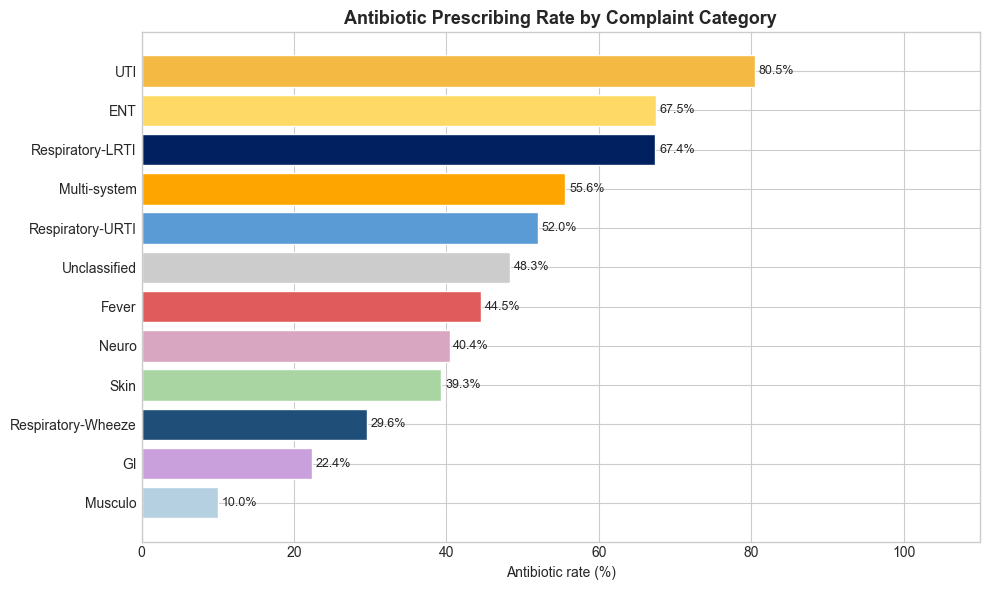

In [20]:
# ── Antibiotic rate by complaint category ────────────────────────────────────
ab_by_cat = (
    df.groupby('complaint_category')['has_antibiotic']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'ab_rate', 'count': 'n'})
    .sort_values('ab_rate', ascending=False)
)
ab_by_cat['ab_rate_pct'] = (ab_by_cat['ab_rate'] * 100).round(1)

fig, ax = plt.subplots(figsize=(10, 6))
bar_colors = [cat_colors.get(k, '#888888') for k in ab_by_cat.index]
bars = ax.barh(ab_by_cat.index[::-1], ab_by_cat['ab_rate_pct'].values[::-1],
               color=bar_colors[::-1], edgecolor='white')
for bar, v in zip(bars, ab_by_cat['ab_rate_pct'].values[::-1]):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{v}%', va='center', fontsize=9)
ax.set_title('Antibiotic Prescribing Rate by Complaint Category',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Antibiotic rate (%)')
ax.set_xlim(0, 110)
plt.tight_layout()
savefig('08_ab_rate_by_complaint')
plt.show()

In [21]:
# ── has_fever and has_respiratory rates ───────────────────────────────────────
fever_n = df['has_fever'].sum()
resp_n  = df['has_respiratory'].sum()
both_n  = ((df['has_fever'] == 1) & (df['has_respiratory'] == 1)).sum()
print(f'Fever flag (has_fever=1)              : {fever_n:,} ({100*fever_n/total:.1f}%)')
print(f'Respiratory flag (has_respiratory=1)  : {resp_n:,} ({100*resp_n/total:.1f}%)')
print(f'Both fever + respiratory              : {both_n:,} ({100*both_n/total:.1f}%)')

Fever flag (has_fever=1)              : 190,244 (29.1%)
Respiratory flag (has_respiratory=1)  : 410,152 (62.7%)
Both fever + respiratory              : 85,623 (13.1%)


Encounters with duration recorded: 123,622 (18.9%)
Duration summary (days):
count   123622.00
mean         2.99
std          7.67
min          0.00
25%          1.00
50%          1.00
75%          3.00
max        360.00
  Saved: D:/Academic/MD Research 2025/AMS_2026/EDA_figures\09_complaint_duration.png


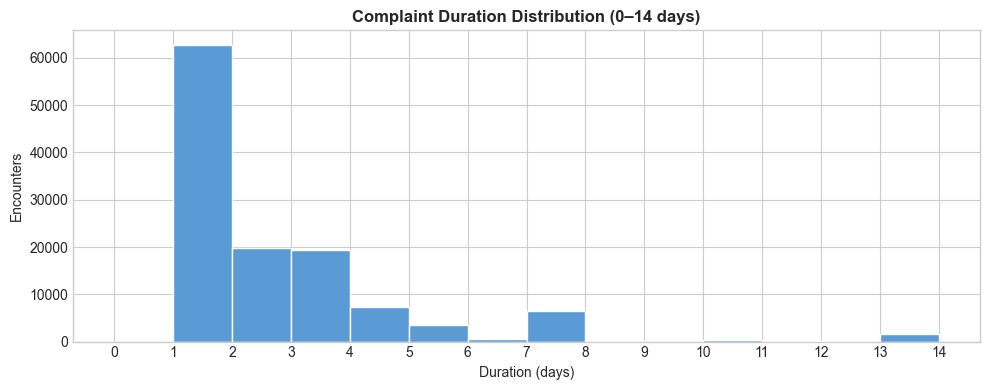

In [22]:
# ── Complaint duration distribution ──────────────────────────────────────────
dur = df['complaint_duration_days'].dropna()
print(f'Encounters with duration recorded: {len(dur):,} ({100*len(dur)/total:.1f}%)')
print('Duration summary (days):')
print(dur.describe().to_string())

fig, ax = plt.subplots(figsize=(10, 4))
dur_clipped = dur[dur <= 14]   # focus on 0–14 days (>14 are outliers)
ax.hist(dur_clipped, bins=14, color='#5B9BD5', edgecolor='white')
ax.set_title('Complaint Duration Distribution (0–14 days)', fontweight='bold')
ax.set_xlabel('Duration (days)')
ax.set_ylabel('Encounters')
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.tight_layout()
savefig('09_complaint_duration')
plt.show()

---
## Section 6 — Prescriber Behaviour

In [23]:
# ── Prescriber-level antibiotic rates ────────────────────────────────────────
prescriber = (
    df.groupby('prescriber_pseudo_id')
    .agg(
        total_encounters=('OPDID', 'count'),
        ab_encounters=('has_antibiotic', 'sum'),
        watch_encounters=('has_watch_antibiotic', 'sum'),
        broad_encounters=('has_broad_spectrum', 'sum'),
    )
    .reset_index()
)
prescriber['ab_rate']    = (prescriber['ab_encounters'] / prescriber['total_encounters'] * 100).round(1)
prescriber['watch_rate'] = (prescriber['watch_encounters'] / prescriber['total_encounters'] * 100).round(1)
prescriber['broad_rate'] = (prescriber['broad_encounters'] / prescriber['total_encounters'] * 100).round(1)

print(f'Unique prescribers: {len(prescriber):,}')
print('\nPrescriber antibiotic rate summary:')
print(prescriber['ab_rate'].describe().to_string())

Unique prescribers: 131

Prescriber antibiotic rate summary:
count   131.00
mean     27.58
std      34.33
min       0.00
25%       0.00
50%      11.60
75%      49.35
max     100.00


  Saved: D:/Academic/MD Research 2025/AMS_2026/EDA_figures\10_prescriber_behaviour.png


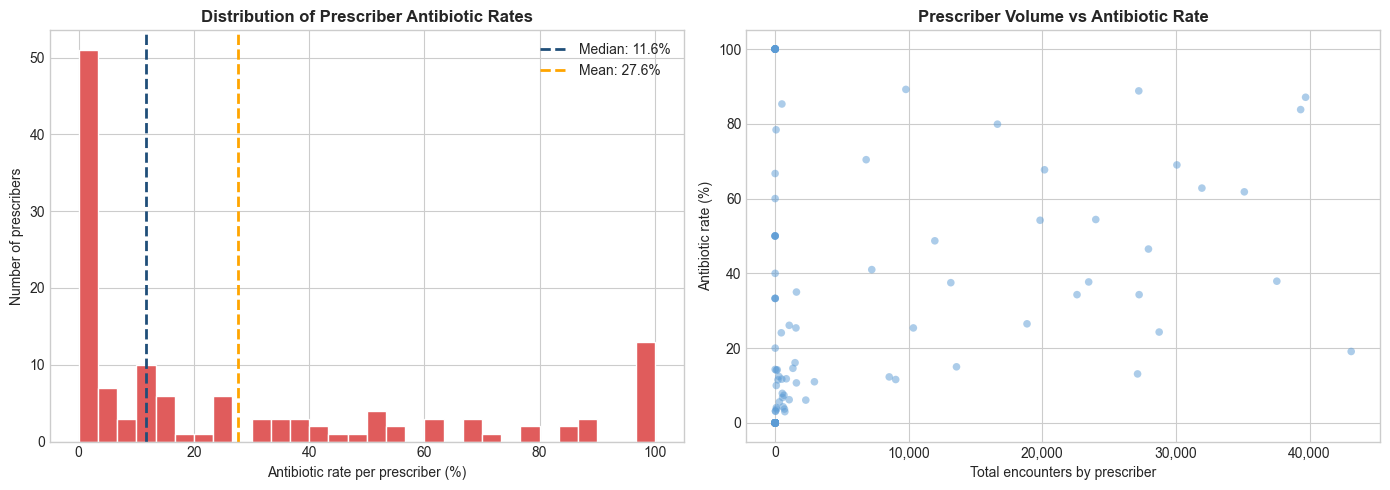

In [24]:
# ── Prescriber antibiotic rate distribution ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of prescriber AB rates
axes[0].hist(prescriber['ab_rate'], bins=30,
             color='#E05C5C', edgecolor='white')
axes[0].axvline(prescriber['ab_rate'].median(), color='#1F4E79',
                linestyle='--', linewidth=2,
                label=f'Median: {prescriber["ab_rate"].median():.1f}%')
axes[0].axvline(prescriber['ab_rate'].mean(), color='#FFA500',
                linestyle='--', linewidth=2,
                label=f'Mean: {prescriber["ab_rate"].mean():.1f}%')
axes[0].set_title('Distribution of Prescriber Antibiotic Rates',
                  fontweight='bold')
axes[0].set_xlabel('Antibiotic rate per prescriber (%)')
axes[0].set_ylabel('Number of prescribers')
axes[0].legend()

# Scatter: encounters vs AB rate (bubble = prescriber volume)
axes[1].scatter(
    prescriber['total_encounters'],
    prescriber['ab_rate'],
    alpha=0.5, color='#5B9BD5', s=30, edgecolors='none'
)
axes[1].set_title('Prescriber Volume vs Antibiotic Rate', fontweight='bold')
axes[1].set_xlabel('Total encounters by prescriber')
axes[1].set_ylabel('Antibiotic rate (%)')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
savefig('10_prescriber_behaviour')
plt.show()

In [25]:
# ── Encounters per prescriber ─────────────────────────────────────────────────
print('Encounters per prescriber summary:')
print(prescriber['total_encounters'].describe().to_string())

# High vs low prescribers
high = prescriber[prescriber['ab_rate'] >= 75]
low  = prescriber[prescriber['ab_rate'] <= 25]
print(f'\nHigh prescribers (rate >= 75%): {len(high):,} prescribers')
print(f'Low prescribers  (rate <= 25%): {len(low):,} prescribers')

Encounters per prescriber summary:
count     131.00
mean     4991.80
std     10441.47
min         1.00
25%         1.00
50%         5.00
75%      1528.50
max     43119.00

High prescribers (rate >= 75%): 20 prescribers
Low prescribers  (rate <= 25%): 81 prescribers


---
## Section 7 — Temporal Patterns

  Saved: D:/Academic/MD Research 2025/AMS_2026/EDA_figures\11_temporal_monthly.png


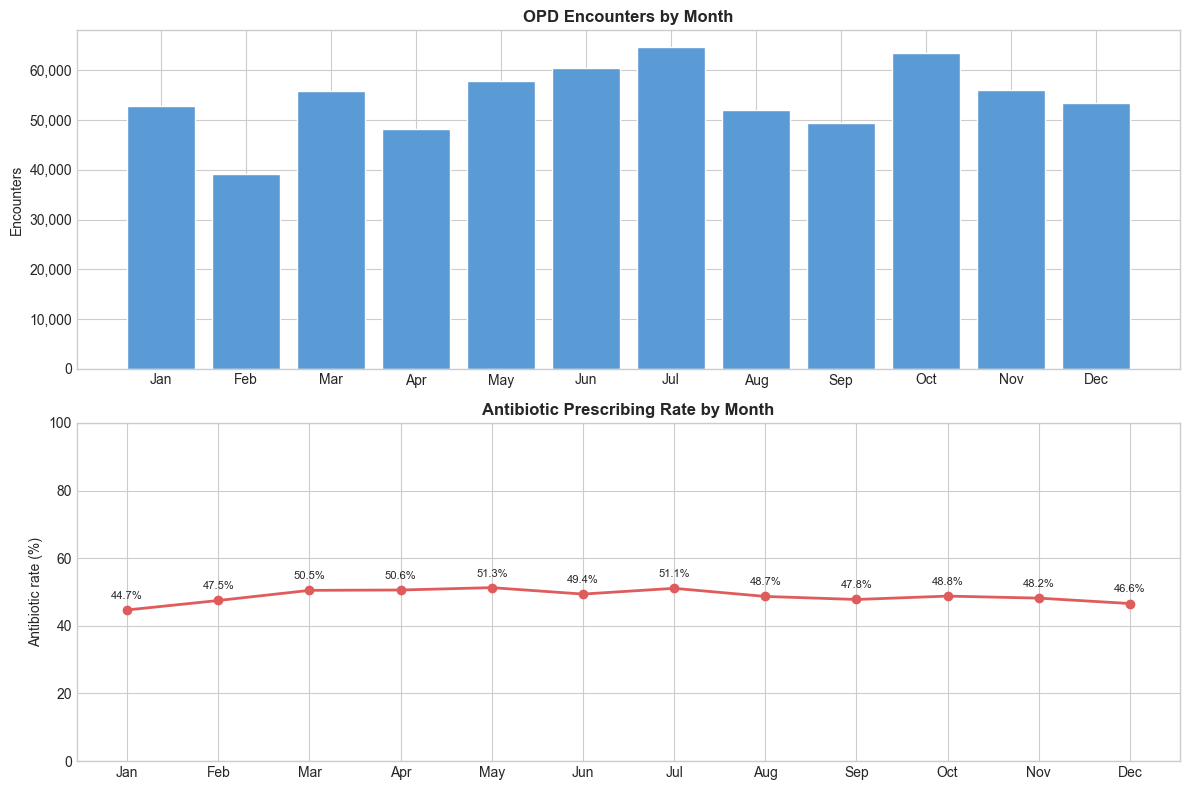

In [26]:
# ── Encounters by month ───────────────────────────────────────────────────────
month_counts = df['visit_month'].value_counts().sort_index()
ab_by_month  = (
    df.groupby('visit_month')['has_antibiotic']
    .mean() * 100
).round(1)

month_labels = ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec']

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Encounters per month
present_months = sorted(month_counts.index)
axes[0].bar([month_labels[m-1] for m in present_months],
            month_counts[present_months].values,
            color='#5B9BD5', edgecolor='white')
axes[0].set_title('OPD Encounters by Month', fontweight='bold')
axes[0].set_ylabel('Encounters')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Antibiotic rate per month
axes[1].plot([month_labels[m-1] for m in present_months],
             ab_by_month[present_months].values,
             marker='o', color='#E05C5C', linewidth=2)
axes[1].set_title('Antibiotic Prescribing Rate by Month', fontweight='bold')
axes[1].set_ylabel('Antibiotic rate (%)')
axes[1].set_ylim(0, 100)
for x, y in enumerate(ab_by_month[present_months].values):
    axes[1].annotate(f'{y}%', (x, y), textcoords='offset points',
                     xytext=(0, 8), ha='center', fontsize=8)

plt.tight_layout()
savefig('11_temporal_monthly')
plt.show()

  Saved: D:/Academic/MD Research 2025/AMS_2026/EDA_figures\12_temporal_hourly.png


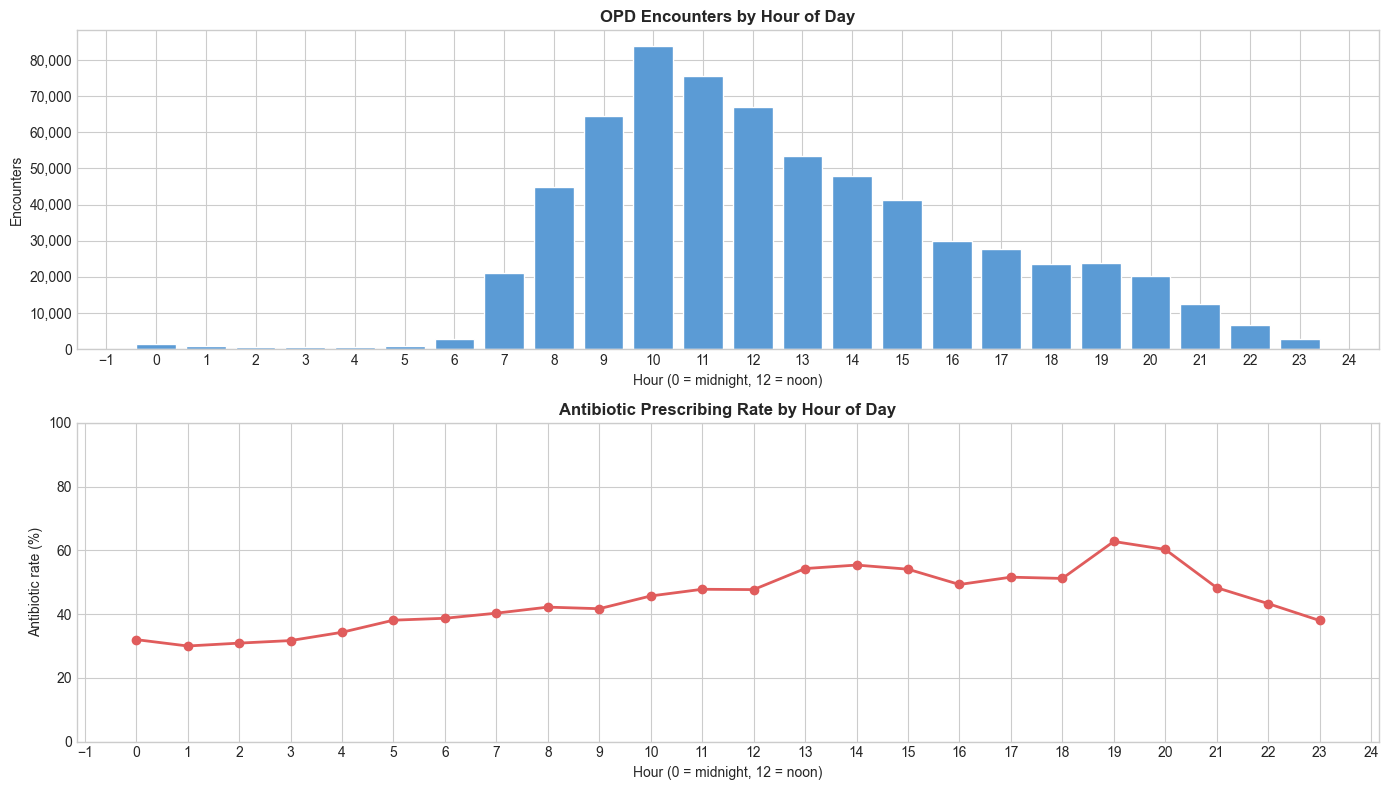

In [27]:
# ── Encounters by hour ────────────────────────────────────────────────────────
hour_counts = df['visit_hour'].value_counts().sort_index()
ab_by_hour  = (
    df.groupby('visit_hour')['has_antibiotic']
    .mean() * 100
).round(1)

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Encounters per hour
axes[0].bar(hour_counts.index, hour_counts.values,
            color='#5B9BD5', edgecolor='white')
axes[0].set_title('OPD Encounters by Hour of Day', fontweight='bold')
axes[0].set_ylabel('Encounters')
axes[0].set_xlabel('Hour (0 = midnight, 12 = noon)')
axes[0].xaxis.set_major_locator(mticker.MultipleLocator(1))
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# AB rate per hour
axes[1].plot(ab_by_hour.index, ab_by_hour.values,
             marker='o', color='#E05C5C', linewidth=2)
axes[1].set_title('Antibiotic Prescribing Rate by Hour of Day', fontweight='bold')
axes[1].set_ylabel('Antibiotic rate (%)')
axes[1].set_xlabel('Hour (0 = midnight, 12 = noon)')
axes[1].set_ylim(0, 100)
axes[1].xaxis.set_major_locator(mticker.MultipleLocator(1))

plt.tight_layout()
savefig('12_temporal_hourly')
plt.show()

prescriber_hourly_load added.

Summary:
count   653926.00
mean        16.11
std          8.76
min          1.00
25%         10.00
50%         15.00
75%         21.00
max         70.00

Top 10 most common load values:
prescriber_hourly_load
14    35616
13    35594
15    33990
16    33920
12    33912
11    33264
17    30464
10    28400
18    27972
9     26775
  Saved: D:/Academic/MD Research 2025/AMS_2026/EDA_figures\16_workload_analysis.png


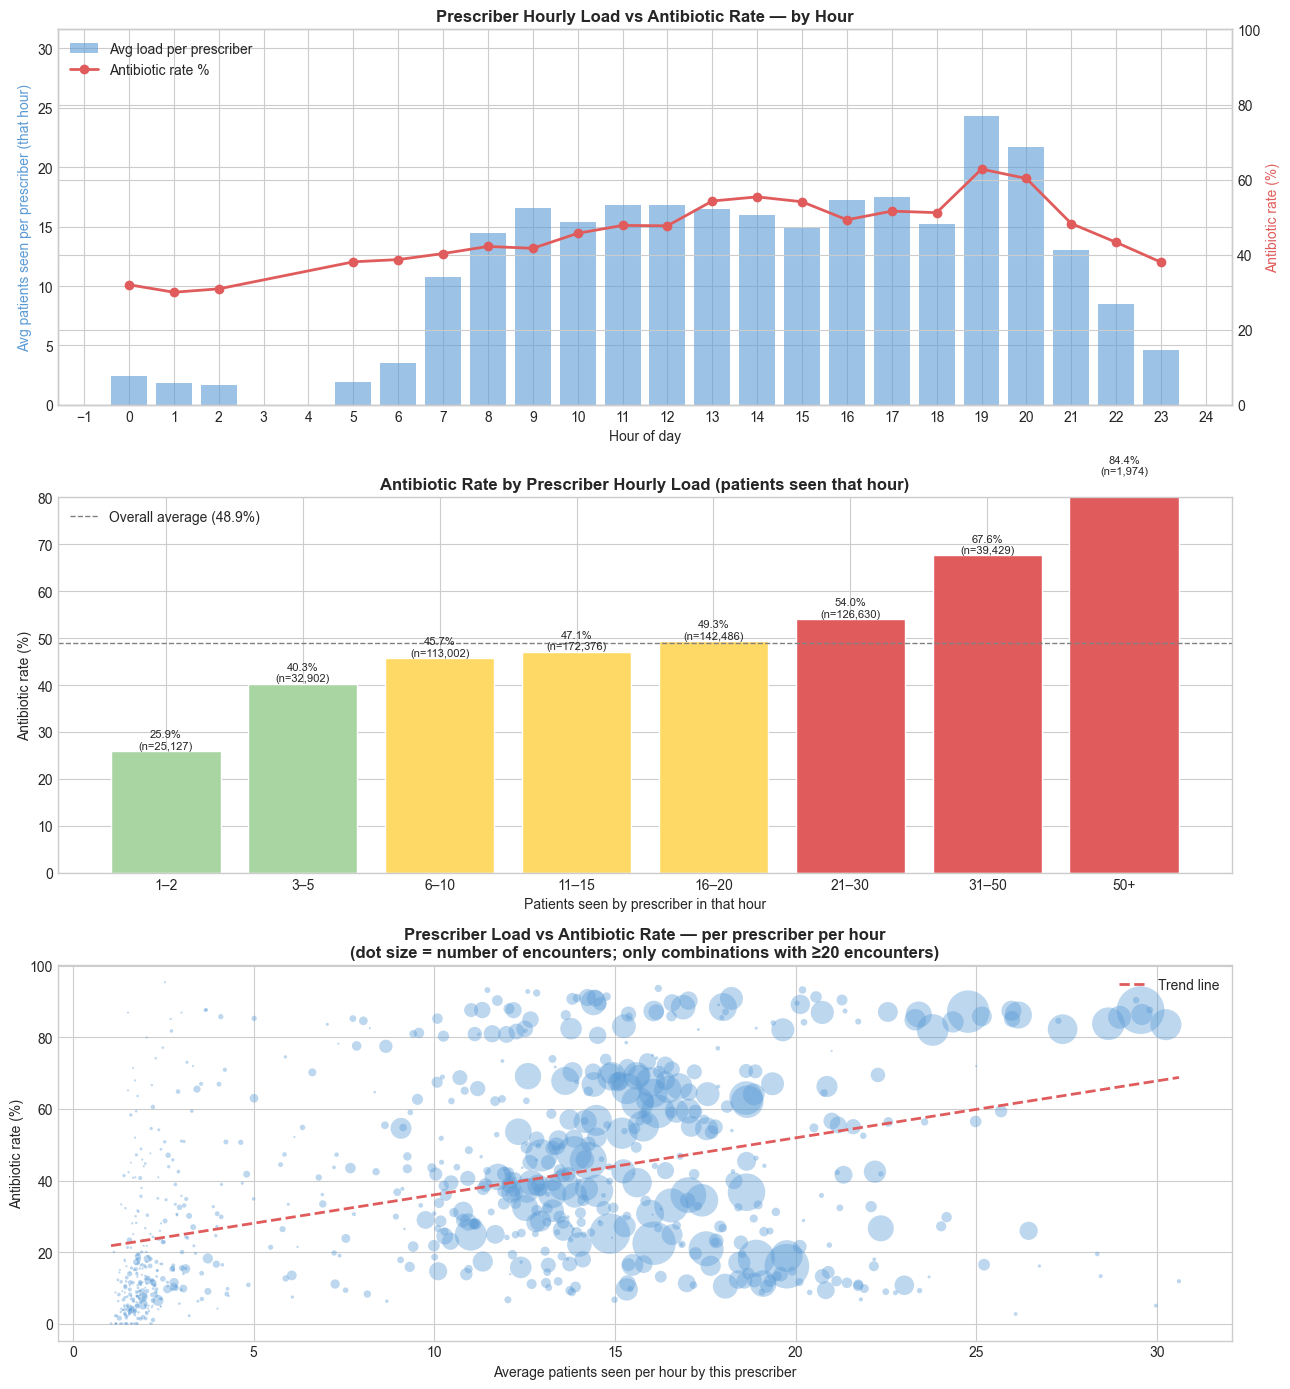


Antibiotic rate by load bin:
  load_bin       n  ab_rate_pct
0      1–2   25127        25.90
1      3–5   32902        40.30
2     6–10  113002        45.70
3    11–15  172376        47.10
4    16–20  142486        49.30
5    21–30  126630        54.00
6    31–50   39429        67.60
7      50+    1974        84.40


In [34]:
# =============================================================================
# WORKLOAD ANALYSIS — Add to EDA notebook after Section 7 (hourly cell)
# Add these as TWO new cells
# =============================================================================

# ─────────────────────────────────────────────────────────────────────────────
# CELL A — Calculate prescriber_hourly_load and add to dataframe
# ─────────────────────────────────────────────────────────────────────────────

# Extract visit date (day only, no time)
df['visit_date'] = df['DateTimeOfVisit'].dt.date

# For each encounter: how many patients did this prescriber see
# in this same hour on this same day?
prescriber_load = (
    df.groupby(['prescriber_pseudo_id', 'visit_date', 'visit_hour'])
    .size()
    .reset_index(name='prescriber_hourly_load')
)

df = df.merge(
    prescriber_load,
    on=['prescriber_pseudo_id', 'visit_date', 'visit_hour'],
    how='left'
)

print("prescriber_hourly_load added.")
print(f"\nSummary:")
print(df['prescriber_hourly_load'].describe().to_string())
print(f"\nTop 10 most common load values:")
print(df['prescriber_hourly_load'].value_counts().head(10).to_string())


# ─────────────────────────────────────────────────────────────────────────────
# CELL B — Visualise workload vs antibiotic rate
# ─────────────────────────────────────────────────────────────────────────────

import matplotlib.ticker as mticker
import numpy as np

fig, axes = plt.subplots(3, 1, figsize=(13, 14))

# ── Plot 1: Average prescriber load per hour vs antibiotic rate ──────────────
# For each hour: average load per prescriber AND average AB rate
hourly_summary = (
    df.groupby('visit_hour')
    .agg(
        avg_load=('prescriber_hourly_load', 'mean'),
        ab_rate=('has_antibiotic', 'mean'),
        n_encounters=('OPDID', 'count')
    )
    .reset_index()
)
hourly_summary['ab_rate_pct'] = (hourly_summary['ab_rate'] * 100).round(1)
hourly_summary['avg_load']    = hourly_summary['avg_load'].round(1)

# Only plot hours with meaningful encounter volume (>= 500)
hourly_plot = hourly_summary[hourly_summary['n_encounters'] >= 500]

ax1 = axes[0]
ax2 = ax1.twinx()

bars = ax1.bar(hourly_plot['visit_hour'],
               hourly_plot['avg_load'],
               color='#5B9BD5', alpha=0.6, label='Avg load per prescriber')
ax2.plot(hourly_plot['visit_hour'],
         hourly_plot['ab_rate_pct'],
         color='#E05C5C', marker='o', linewidth=2,
         label='Antibiotic rate %')

ax1.set_xlabel('Hour of day')
ax1.set_ylabel('Avg patients seen per prescriber (that hour)', color='#5B9BD5')
ax2.set_ylabel('Antibiotic rate (%)', color='#E05C5C')
ax1.set_title('Prescriber Hourly Load vs Antibiotic Rate — by Hour',
              fontsize=12, fontweight='bold')
ax1.set_ylim(0, hourly_plot['avg_load'].max() * 1.3)
ax2.set_ylim(0, 100)
ax1.xaxis.set_major_locator(mticker.MultipleLocator(1))

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

# ── Plot 2: Antibiotic rate by load bins ─────────────────────────────────────
# Group prescriber_hourly_load into bins and show AB rate per bin
bins   = [0, 2, 5, 10, 15, 20, 30, 50, 9999]
labels = ['1–2', '3–5', '6–10', '11–15', '16–20', '21–30', '31–50', '50+']

df['load_bin'] = pd.cut(df['prescriber_hourly_load'],
                         bins=bins, labels=labels, right=True)

load_ab = (
    df.groupby('load_bin', observed=True)
    .agg(
        ab_rate=('has_antibiotic', 'mean'),
        n=('OPDID', 'count')
    )
    .reset_index()
)
load_ab['ab_rate_pct'] = (load_ab['ab_rate'] * 100).round(1)

bar_colors = ['#A8D5A2' if r < 45 else '#FFD966' if r < 52 else '#E05C5C'
              for r in load_ab['ab_rate_pct']]

bars2 = axes[1].bar(load_ab['load_bin'].astype(str),
                    load_ab['ab_rate_pct'],
                    color=bar_colors, edgecolor='white')
for bar, (_, row) in zip(bars2, load_ab.iterrows()):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 f"{row['ab_rate_pct']}%\n(n={row['n']:,})",
                 ha='center', fontsize=8)
axes[1].set_title('Antibiotic Rate by Prescriber Hourly Load (patients seen that hour)',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Patients seen by prescriber in that hour')
axes[1].set_ylabel('Antibiotic rate (%)')
axes[1].set_ylim(0, 80)
axes[1].axhline(48.9, color='grey', linestyle='--', linewidth=1,
                label='Overall average (48.9%)')
axes[1].legend()

# ── Plot 3: Scatter — individual prescriber load vs their AB rate ─────────────
# Each dot = one unique (prescriber, hour) combination across the whole dataset
prescriber_hour_summary = (
    df.groupby(['prescriber_pseudo_id', 'visit_hour'])
    .agg(
        avg_load=('prescriber_hourly_load', 'mean'),
        ab_rate=('has_antibiotic', 'mean'),
        n=('OPDID', 'count')
    )
    .reset_index()
)
# Only include combinations with at least 20 encounters for reliability
prescriber_hour_plot = prescriber_hour_summary[
    prescriber_hour_summary['n'] >= 20
].copy()
prescriber_hour_plot['ab_rate_pct'] = prescriber_hour_plot['ab_rate'] * 100

axes[2].scatter(
    prescriber_hour_plot['avg_load'],
    prescriber_hour_plot['ab_rate_pct'],
    alpha=0.4, s=prescriber_hour_plot['n'] / 10,
    color='#5B9BD5', edgecolors='none'
)

# Add trend line
z = np.polyfit(prescriber_hour_plot['avg_load'],
               prescriber_hour_plot['ab_rate_pct'], 1)
p = np.poly1d(z)
x_line = np.linspace(prescriber_hour_plot['avg_load'].min(),
                     prescriber_hour_plot['avg_load'].max(), 100)
axes[2].plot(x_line, p(x_line), color='#E05C5C',
             linewidth=2, linestyle='--', label='Trend line')
axes[2].set_title(
    'Prescriber Load vs Antibiotic Rate — per prescriber per hour\n'
    '(dot size = number of encounters; only combinations with ≥20 encounters)',
    fontsize=12, fontweight='bold')
axes[2].set_xlabel('Average patients seen per hour by this prescriber')
axes[2].set_ylabel('Antibiotic rate (%)')
axes[2].legend()

plt.tight_layout()
savefig('16_workload_analysis')
plt.show()

# ── Summary stats ─────────────────────────────────────────────────────────────
print("\nAntibiotic rate by load bin:")
print(load_ab[['load_bin', 'n', 'ab_rate_pct']].to_string())

---
## Section 8 — Feature Relationships

In [29]:
# Replace MySQL null strings with proper NaN
df.replace(r'\N', np.nan, inplace=True)

# Re-cast numerical columns that may have been read as text
for col in ['PatientWeight', 'complaint_duration_days', 
            'visit_month', 'visit_hour', 'age_months',
            'num_distinct_drugs', 'num_antibiotics']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print("Done — \\N values replaced with NaN")
print(df[numerical_cols].dtypes)

Done — \N values replaced with NaN
age_months                 float64
PatientWeight              float64
num_distinct_drugs           int64
num_antibiotics              int64
has_antibiotic               int64
has_watch_antibiotic         int64
has_broad_spectrum           int64
has_fever                    int64
has_respiratory              int64
complaint_duration_days    float64
visit_month                  int64
visit_hour                   int64
dtype: object


  Saved: D:/Academic/MD Research 2025/AMS_2026/EDA_figures\13_correlation_heatmap.png


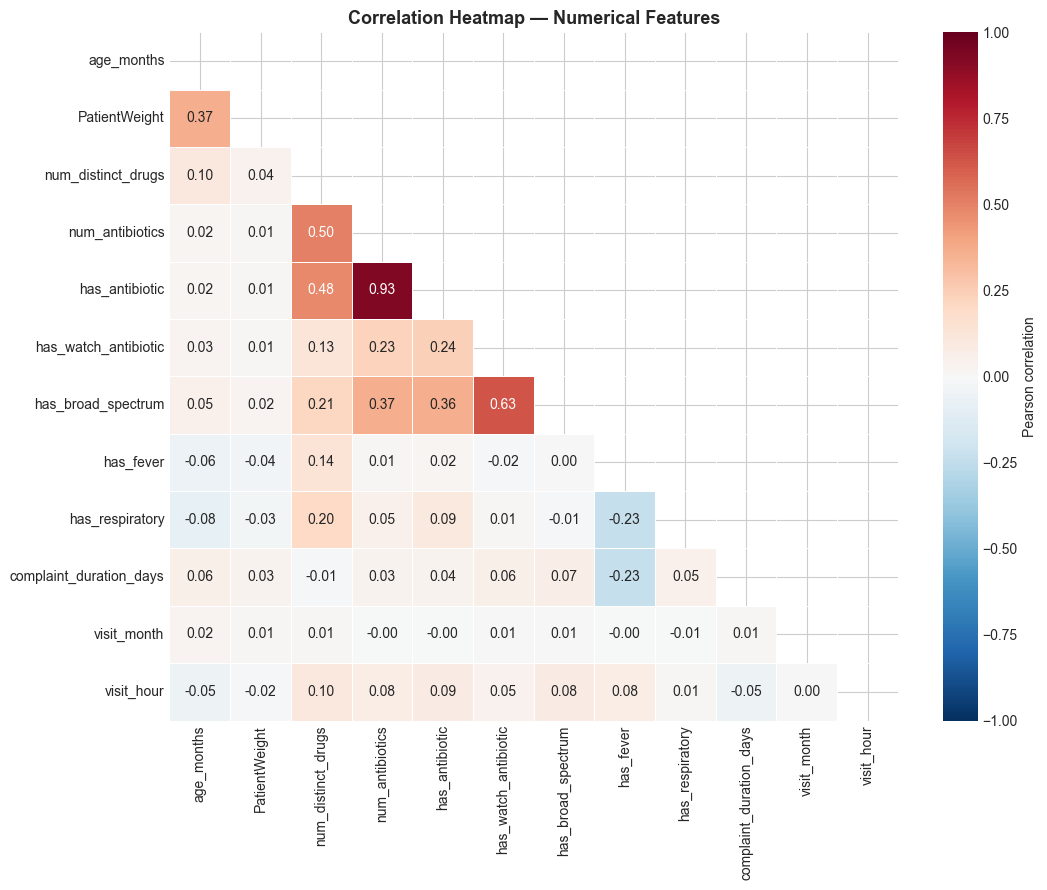

In [30]:
# ── Correlation heatmap — numerical features ──────────────────────────────────
numerical_cols = [
    'age_months', 'PatientWeight', 'num_distinct_drugs',
    'num_antibiotics', 'has_antibiotic', 'has_watch_antibiotic',
    'has_broad_spectrum', 'has_fever', 'has_respiratory',
    'complaint_duration_days', 'visit_month', 'visit_hour'
]
corr = df[numerical_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Pearson correlation'})
ax.set_title('Correlation Heatmap — Numerical Features', fontsize=13, fontweight='bold')
plt.tight_layout()
savefig('13_correlation_heatmap')
plt.show()

  Saved: D:/Academic/MD Research 2025/AMS_2026/EDA_figures\14_ab_rate_category_age_heatmap.png


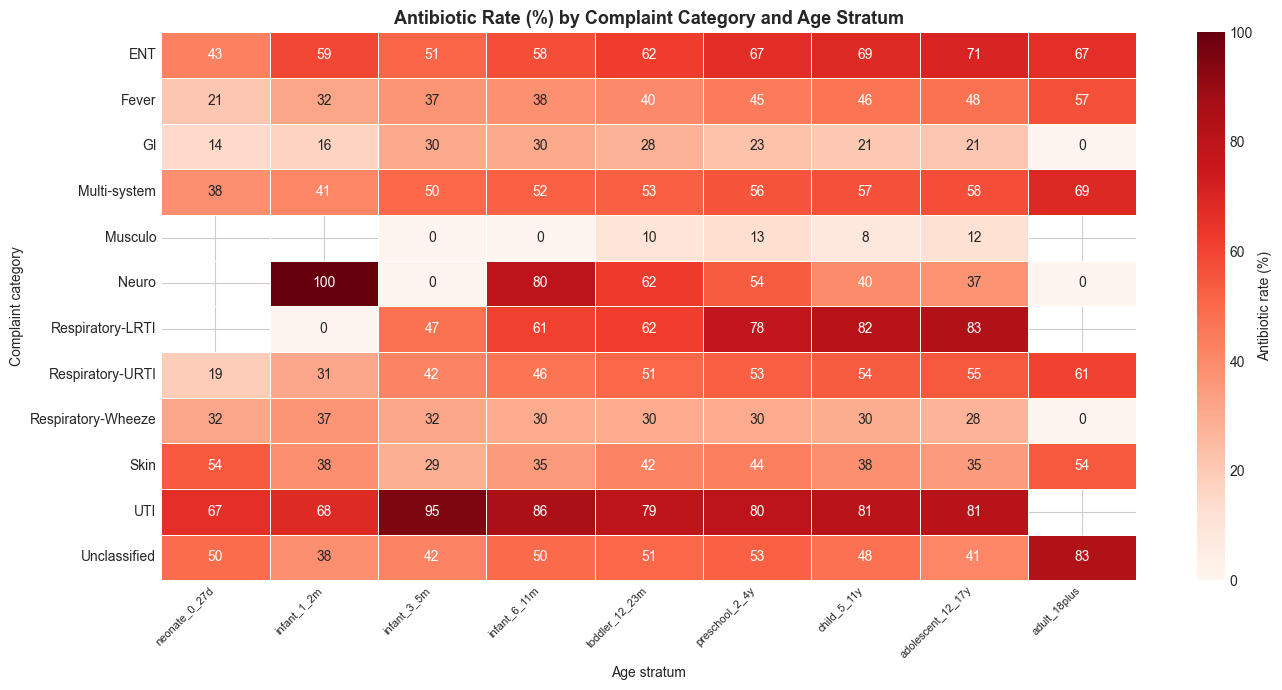

In [31]:
# ── Antibiotic rate: complaint category × age stratum ────────────────────────
pivot = (
    df.groupby(['complaint_category', 'age_stratum'])['has_antibiotic']
    .mean()
    .unstack()
    .reindex(columns=[a for a in age_order if a in df['age_stratum'].values])
    * 100
).round(1)

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='Reds',
            linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Antibiotic rate (%)'})
ax.set_title('Antibiotic Rate (%) by Complaint Category and Age Stratum',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Age stratum')
ax.set_ylabel('Complaint category')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
savefig('14_ab_rate_category_age_heatmap')
plt.show()

  Saved: D:/Academic/MD Research 2025/AMS_2026/EDA_figures\15_aware_by_complaint.png


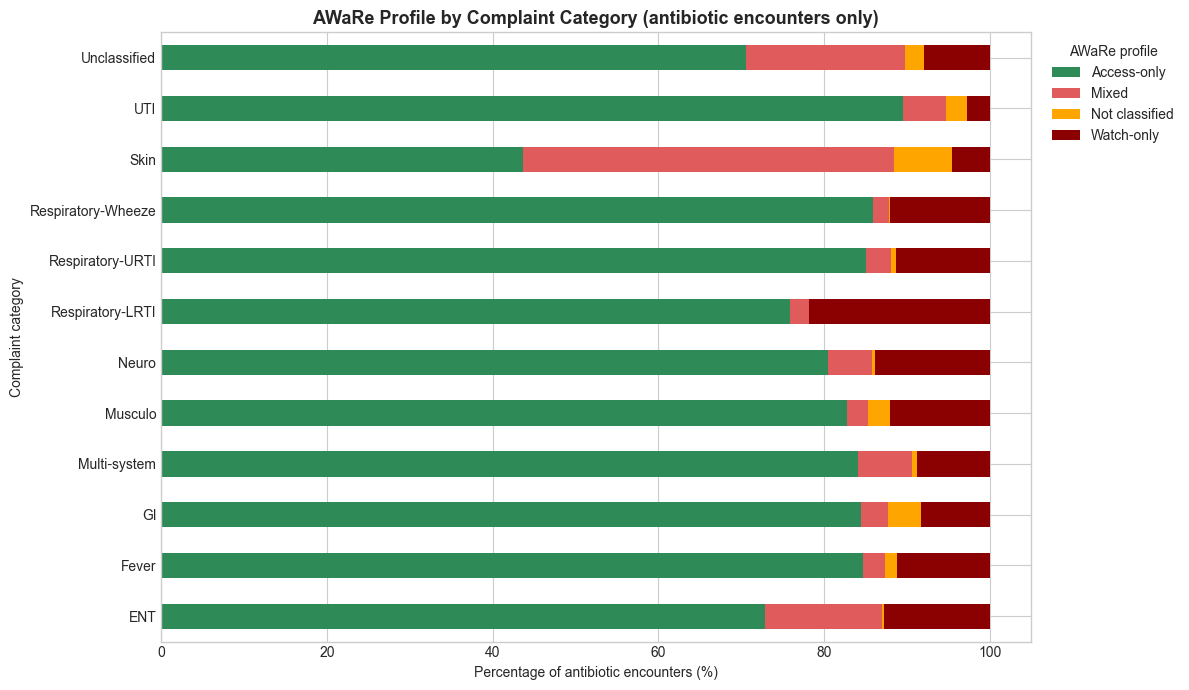

In [32]:
# ── AWaRe profile vs complaint category ──────────────────────────────────────
aware_cat = (
    df[df['has_antibiotic'] == 1]
    .groupby(['complaint_category', 'aware_profile'])
    .size()
    .unstack(fill_value=0)
)
# Normalise to row percentages
aware_cat_pct = aware_cat.div(aware_cat.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(12, 7))
aware_cat_pct.plot(kind='barh', stacked=True, ax=ax,
                   color=['#2E8B57', '#E05C5C', '#FFA500', '#8B0000', '#AAAAAA'])
ax.set_title('AWaRe Profile by Complaint Category (antibiotic encounters only)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Percentage of antibiotic encounters (%)')
ax.set_ylabel('Complaint category')
ax.legend(title='AWaRe profile', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
savefig('15_aware_by_complaint')
plt.show()

In [33]:
# ── EDA Summary ───────────────────────────────────────────────────────────────
print('=' * 60)
print('EDA COMPLETE — SUMMARY')
print('=' * 60)
print(f'  Total encounters analysed : {total:,}')
print(f'  Antibiotic rate           : {ab_rate:.1f}%')
print(f'  Unique prescribers        : {len(prescriber):,}')
print(f'  Prescriber rate range     : {prescriber["ab_rate"].min():.1f}% '
      f'to {prescriber["ab_rate"].max():.1f}%')
print(f'  Dominant complaint        : {cat_counts.index[0]} '
      f'({100*cat_counts.iloc[0]/total:.1f}%)')
print(f'  Figures saved to          : {FIGURES_DIR}')
print()
print('Next step: Clustering analysis')

EDA COMPLETE — SUMMARY
  Total encounters analysed : 653,926
  Antibiotic rate           : 48.9%
  Unique prescribers        : 131
  Prescriber rate range     : 0.0% to 100.0%
  Dominant complaint        : Respiratory-URTI (45.2%)
  Figures saved to          : D:/Academic/MD Research 2025/AMS_2026/EDA_figures

Next step: Clustering analysis
